In [1]:

import pandas as pd



In [3]:
train_df = pd.read_csv("train_20newsgroups.csv")
test_df = pd.read_csv("test_20newsgroups.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)



Train Shape: (200, 3)
Test Shape: (100, 3)


In [4]:
print("Train Columns:")
print(train_df.columns)

print("\nTest Columns:")
print(test_df.columns)

Train Columns:
Index(['text', 'target', 'target_name'], dtype='object')

Test Columns:
Index(['text', 'target', 'target_name'], dtype='object')


In [5]:
train_df = train_df.dropna()
test_df = test_df.dropna()

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (200, 3)
Test Shape: (100, 3)


In [7]:
X_train = train_df["text"]
y_train = train_df["target"]

X_test = test_df["text"]
y_test = test_df["target"]

print("Training Documents:", len(X_train))
print("Testing Documents:", len(X_test))

Training Documents: 200
Testing Documents: 100


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape :", X_test_tfidf.shape)

Training TF-IDF Shape: (200, 74)
Testing TF-IDF Shape : (100, 74)


In [9]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

print("SVM model created successfully!")

SVM model created successfully!


In [11]:
model.fit(X_train_tfidf, y_train)

SVC(kernel='linear')

In [12]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed successfully!")
print("Predicted Labels:", y_pred[:20])

Prediction completed successfully!
Predicted Labels: [0 1 2 3 4 8 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.98


In [14]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      0.80      0.89        10
           6       1.00      1.00      1.00        10
           7       1.00      1.00      1.00        10
           8       0.83      1.00      0.91        10
           9       1.00      1.00      1.00        10

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [15]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0  0  0  0  0  0  0  0]
 [ 0 10  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0 10  0  0  0  0  0]
 [ 0  0  0  0  0  8  0  0  2  0]
 [ 0  0  0  0  0  0 10  0  0  0]
 [ 0  0  0  0  0  0  0 10  0  0]
 [ 0  0  0  0  0  0  0  0 10  0]
 [ 0  0  0  0  0  0  0  0  0 10]]


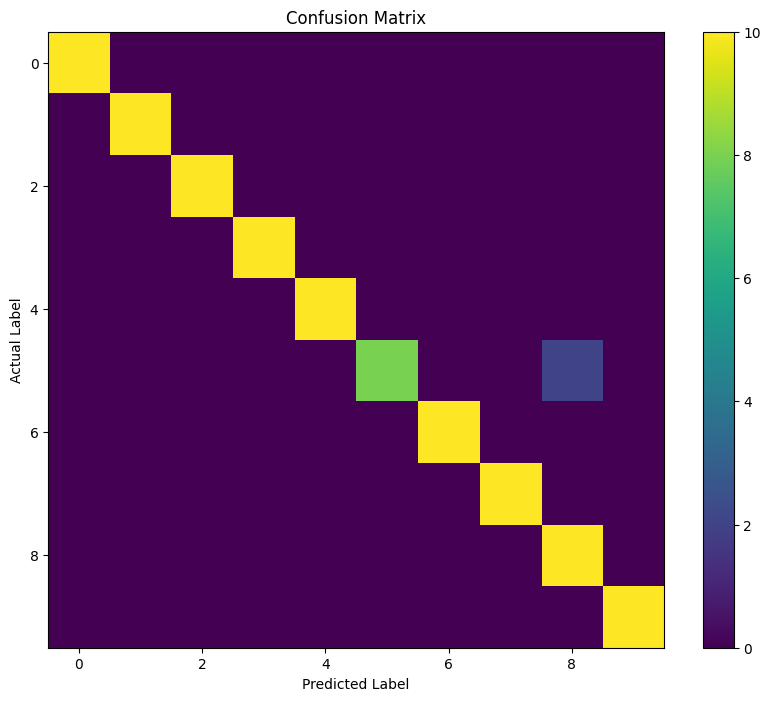

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.show()